# 打开 Notebook

# 在 Colab 中打开
<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ai-agents-the-definitive-guide/blob/main/CH02/ch02_CoT.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>



# 关于这个 Notebook

这个 Notebook 是一个面向 data analysis agent（数据分析智能体）的动手模板：它把 **LangChain/LangGraph tool-calling（工具调用）ReAct agent** 与一个很轻量的 **LangGraph** 包装层结合起来。示例展示如何通过 CoT（Chain of Thought，思维链）风格的指令驱动一个沙箱化 **Python REPL** 工具：加载 CSV、计算统计量并生成简单图表，同时返回最终答案、恢复后的图表和中间工具调用步骤。

## 它展示了什么

* 通过 `.env` / 环境变量配置 `OPENAI_API_KEY`，如果没有配置则退回到交互式输入。
* 一个沙箱化 Python REPL 工具（`PyodideSandboxTool`）：在隔离的 Pyodide/WASM 环境中运行模型生成的代码，把结果写到 stdout，并将错误以 traceback 形式暴露出来。
* CoT 风格的系统指令：先给出推理结构（描述 → 模式 → 总结），再把沙箱和执行机制放在单独的指令块中。
* 使用 `create_react_agent` 创建 tool-calling ReAct agent（LangGraph 预构建组件；在 LangChain v1 中对应 `create_agent`）。
* 一个最小化 LangGraph：只有一个节点运行 Agent，并暴露以下状态：

  * `messages`：消息历史
  * `output`：最终答案
  * `chart_path` / `chart_svg`：恢复后的图表
  * `intermediate_steps`：工具调用及其 observations（观察结果）。
* 运行时即时创建 demo CSV（演示数据），让示例可复现。
* 使用 Mermaid 渲染单节点图结构。

## 你将运行什么

1. 从 `.env` / 环境变量读取 `OPENAI_API_KEY`，或者交互式输入。
2. 定义一个沙箱化 Python REPL 工具。因为沙箱文件系统对宿主不可见，所以 Prompt 会让它通过 stdout 输出 base64 编码的 SVG，而不是把图表保存成文件。
3. 构建一个 tool-calling（ReAct）Agent，并通过 Prompt 要求它：

   * 描述数据集；
   * 找出主要模式；
   * 给出简短总结；
   * 当目标列存在时，调用 REPL 计算指标并生成一张柱状图。
4. 把 Agent 包装进一个单节点 LangGraph，并用一条包含 CSV 数据和目标列的用户消息调用它。
5. 查看最终 Agent 输出和中间工具步骤，以理解执行过程。
6. 查看从沙箱恢复出的柱状图，它会以 SVG 形式直接渲染在单元格中。
7. 可选：查看图结构的 PNG / Mermaid 渲染。

## 它是如何工作的

* **REPL 工具**在隔离的 Pyodide/WASM 沙箱中运行模型生成的 Python，并返回捕获到的 stdout；发生错误时则返回 traceback。这个沙箱有自己的临时文件系统，因此其中用 `open(...)` 写出的内容对 Notebook 宿主不可见。也正因为如此，图表会被编码成 base64 SVG，打印在一对标记行之间，再由宿主侧解码恢复。
* **Agent**依据系统指令和对话历史，决定何时调用工具、以及传入什么代码。
* **图节点（graph node）**调用 Agent，捕获 `output` 和 `intermediate_steps`，从工具输出中恢复 SVG 图表，并把这些结果写回 state（状态），方便后续继续串接流程。
* 最后，宿主通过 `IPython.display` **内联渲染 SVG**，同时也会把它保存到磁盘。

## 为什么采用这种模式

* Tool-calling agent 很适合结构化工具使用：模型输出的是结构化 tool-call 参数，而不是自由文本。
* LangGraph 提供了轻量 state wrapper（状态包装层），很容易继续扩展为更大的工作流。
* 沙箱化 REPL 让分析过程可验证：每个统计量和图表都来自你可以检查的代码，同时执行环境又与本机隔离。

## 如何扩展

* 加入文件上传、SQL 或网页抓取工具。
* 在 system prompt 中约束更严格的模板，以获得更一致的报告格式。
* 在生产环境中，把 Pyodide 沙箱替换为容器化或远程沙箱。
* 在返回最终答案前增加验证、报告格式化等节点。

## 运行要求与说明

* 需要有效的 `OPENAI_API_KEY`。
* REPL 已经运行在隔离的 **Pyodide** 沙箱中；生产环境仍应考虑具备资源限制和更强隔离能力的加固型 / 容器化沙箱。
* **沙箱内部不使用 matplotlib，也不直接保存图片文件**：图表通过手写 SVG 字符串，经 stdout 输出，再由宿主恢复。内联展示使用 `IPython.display`，所以在 Notebook 中运行单元格时会看到图表；如果通过 `!python script.py` 运行文件，则不会以内联方式显示。
* `create_react_agent` 在 LangGraph v1 中已经 deprecated（弃用），推荐改用 `from langchain.agents import create_agent`；当前代码仍保留前者，因此只会产生 warning（警告），不会改变示例行为。

# 依赖项

为避免依赖冲突，先卸载部分依赖

In [ ]:

!pip uninstall -y langchain_sandbox langchain-sandbox langchain-core langchain langchain-openai langgraph langgraph-prebuilt langgraph-checkpoint

Found existing installation: langchain-core 1.4.0
Uninstalling langchain-core-1.4.0:
  Successfully uninstalled langchain-core-1.4.0
Found existing installation: langchain 1.3.4
Uninstalling langchain-1.3.4:
  Successfully uninstalled langchain-1.3.4
Found existing installation: langgraph 1.2.4
Uninstalling langgraph-1.2.4:
  Successfully uninstalled langgraph-1.2.4
Found existing installation: langgraph-prebuilt 1.1.0
Uninstalling langgraph-prebuilt-1.1.0:
  Successfully uninstalled langgraph-prebuilt-1.1.0
Found existing installation: langgraph-checkpoint 4.1.1
Uninstalling langgraph-checkpoint-4.1.1:
  Successfully uninstalled langgraph-checkpoint-4.1.1


In [ ]:
!pip install -q \
    langchain-sandbox==0.0.6 \
    langchain-core==0.3.86 \
    langgraph==1.0.1 \
    langchain-openai==0.3.35 \
    langchain \
    python-dotenv==1.0.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.8 MB/s eta 0:00:00


In [ ]:
!curl -fsSL https://deno.land/install.sh | sh
import os
os.environ["PATH"] += ":/root/.deno/bin"

######################################################################## 100.0%
Archive:  /root/.deno/bin/deno.zip
  inflating: /root/.deno/bin/deno    
Deno was installed successfully to /root/.deno/bin/deno
sh: 105: cannot open /dev/tty: No such device or address


# API 配置

In [ ]:
# --- API Key 配置 ---
# 方案 1（推荐）：在项目目录中创建 `.env` 文件，并写入：
# OPENAI_API_KEY=your_openai_key_here
#
# 方案 2：也可以直接通过 Notebook magic 设置：
# %env OPENAI_API_KEY=your_openai_key_here


from dotenv import load_dotenv
import os

load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

print("✅ API key loaded successfully!")


✅ API key loaded successfully!


# 导入依赖

In [ ]:
from typing import TypedDict, List, Any, Dict, Optional
from pathlib import Path
import base64
import re

import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_sandbox import PyodideSandboxTool
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.graph import StateGraph, START, END




/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/base/__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


# 在宿主侧恢复图表

In [ ]:
# 通过 stdout 将图表从沙箱传回宿主时使用的标记，以及宿主侧保存路径。
SVG_BEGIN = "===SVG_B64_BEGIN==="
SVG_END = "===SVG_B64_END==="
CHART_PATH = Path("mean_values_by_city.svg")

def extract_svg_from_messages(
    messages: List[BaseMessage], out_path: Path
) -> Optional[Path]:
    """Find the base64-encoded SVG the sandbox printed to stdout and write it to a
    real file on the host. Returns the path if found, else None."""
    pattern = re.compile(
        re.escape(SVG_BEGIN) + r"(.*?)" + re.escape(SVG_END), re.DOTALL
    )
    for msg in messages:
        content = getattr(msg, "content", "")
        if isinstance(content, list):  # some message contents are lists of blocks
            content = " ".join(str(part) for part in content)
        if not isinstance(content, str):
            continue
        match = pattern.search(content)
        if not match:
            continue
        blob = re.sub(r"\s+", "", match.group(1))  # drop any stray whitespace/newlines
        try:
            svg = base64.b64decode(blob).decode("utf-8")
        except Exception:
            continue
        out_path.write_text(svg, encoding="utf-8")
        return svg  # changed: return the markup so the host can also render it inline
    return None

def show_chart(svg: Optional[str], path: Optional[str]) -> None:
    """Render the chart inline in a Jupyter/Colab cell. Falls back to a plain
    message (and optional PNG export) when not running inside IPython."""
    if not svg:
        print("[warning] No chart was recovered from the sandbox stdout.")
        return
    try:
        # 在 Notebook 中，这会把图表直接绘制到当前单元格输出区域。
        from IPython.display import SVG, display

        display(SVG(svg))
        if path:
            print(f"(also saved to {path})")
        return
    except Exception:
        pass  # not in a notebook / IPython unavailable

    # 非 Notebook 环境下的 fallback（回退方案）：报告文件路径，并可选导出 PNG。
    if path:
        print(f"SVG chart written to: {path} (open in a browser to view)")
        try:
            import cairosvg  # optional: pip install cairosvg

            png_path = Path(path).with_suffix(".png")
            cairosvg.svg2png(url=path, write_to=str(png_path))
            print(f"PNG chart written to: {png_path.resolve()}")
        except Exception as exc:
            print(f"(PNG export skipped: {exc})")

# 工具：Python REPL

In [ ]:
python_repl = PyodideSandboxTool(
    name="python_repl",
    description=(
        "Execute Python code for data analysis. Always print results. Use pandas for "
        "tables. Charts must be emitted as pure SVG strings printed to stdout "
        "(matplotlib is not available, and the sandbox filesystem is not visible to "
        "the host)."
    ),
    allow_net=True,
)
tools = [python_repl]

# CoT（Chain of Thought，思维链）风格的 system prompt

In [ ]:
SYSTEM_INSTRUCTIONS = f"""You are a careful data analysis assistant. Think step by step and be explicit in your reasoning.

Structure your analysis as a clear chain of thought, and present your FINAL ANSWER in these three parts:
1. Describe the dataset: its shape, its columns, and what each column represents.
2. Highlight the patterns or trends you find.
3. Conclude with a clear summary of insights.

--- How to run the analysis ---
To compute metrics or build a chart, call the python_repl tool with code that:
- Loads the CSV data from the user message using io.StringIO
- Prints descriptive statistics
- If a target column exists, computes the mean numeric values grouped by the target
- Builds one grouped bar chart (target categories on the x-axis, numeric means as the bars)
- Prints the key results

--- Returning the chart to the host (required) ---
The sandbox filesystem is NOT visible to the host, so writing the chart with open(...) would lose it.
Instead, assemble the chart as a pure SVG document in a Python string named svg_str, then emit it
base64-encoded between two marker lines:
    import base64
    print("{SVG_BEGIN}")
    print(base64.b64encode(svg_str.encode("utf-8")).decode("ascii"))
    print("{SVG_END}")

--- Sandbox constraints ---
- Do not import matplotlib or matplotlib.pyplot, and do not use plt.show(); charts must be hand-built SVG strings.
- Do not use backslash escape sequences inside Python string literals (no '\\nText' or 'a\\nb').
  For blank lines use print() on its own line; to join multi-line text or SVG fragments use chr(10).join([...]) or "".join([...]).

Return your FINAL ANSWER only after you have executed the analysis successfully."""

# LangGraph state（状态）与节点

In [ ]:
class AgentState(TypedDict):
    messages: List[BaseMessage]
    output: str
    chart_path: Optional[str]
    chart_svg: Optional[str]
    intermediate_steps: Any


llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)

agent = create_react_agent(
    model=llm,
    tools=tools,
    prompt=SYSTEM_INSTRUCTIONS,
)


def agent_node(state: AgentState) -> Dict[str, Any]:
    result = agent.invoke({"messages": state["messages"]})
    messages = result.get("messages", [])

    output = ""
    if messages:
        output = getattr(messages[-1], "content", "") or ""
    svg = extract_svg_from_messages(messages, CHART_PATH)

    return {
        "messages": messages,
        "output": output,
        "chart_path": str(CHART_PATH.resolve()) if svg else None,
        "chart_svg": svg,
        "intermediate_steps": result,
    }

/tmp/ipykernel_2534/3182925875.py:11: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


# 构建一个最小的单节点图

In [ ]:
builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_edge(START, "agent")
builder.add_edge("agent", END)
app = builder.compile()

# Demo dataset and run

In [ ]:
demo_csv = Path("demo.csv")
if not demo_csv.exists():
    df = pd.DataFrame(
        {
            "city": ["A", "A", "B", "B", "C"],
            "sales": [10, 12, 8, 9, 15],
            "cost": [3, 4, 2, 2, 5],
        }
    )
    df.to_csv(demo_csv, index=False)

target = "city"
csv_text = demo_csv.read_text()

human = HumanMessage(
    content=(
        f"Target column: {target}\n\n"
        "CSV data:\n"
        f"{csv_text}"
    )
)

initial_state: AgentState = {
    "messages": [human],
    "output": "",
    "chart_path": None,
    "chart_svg": None,
    "intermediate_steps": [],
}

final = app.invoke(initial_state)

print("\n=== Agent output ===\n")
print(final.get("output", ""))


=== Agent output ===

1. Describe the dataset  
- Shape: 5 rows × 3 columns  
- Columns:
  - `city`: target/category column with values A, B, and C
  - `sales`: numeric measure of sales
  - `cost`: numeric measure of cost

2. Highlight patterns or trends  
- There are 3 unique cities in the data.
- Average values by city:
  - A: sales 11.0, cost 3.5
  - B: sales 8.5, cost 2.0
  - C: sales 15.0, cost 5.0
- City C has the highest average sales and cost.
- City B has the lowest average sales and the lowest average cost.
- City A sits between B and C for both metrics.
- Overall, sales and cost appear to move together across cities: the city with higher sales also tends to have higher cost.

3. Conclude with a clear summary of insights  
- The dataset is small but shows a clear ordering across cities: B lowest, A middle, C highest for both sales and cost.
- This suggests a positive relationship between sales and cost in this sample.
- If you want, I can also help interpret whether the high

# 展示真正从沙箱返回到宿主的图表
在 Notebook 中会直接内联渲染；否则会报告已保存的文件路径。


=== Chart ===



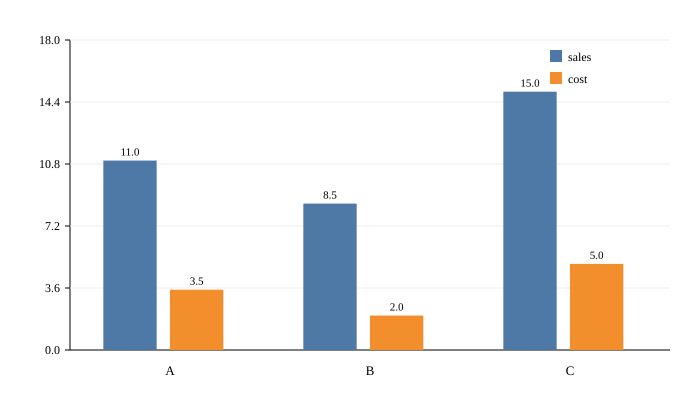

(also saved to /content/mean_values_by_city.svg)

=== Raw result / intermediate info ===

{'messages': [HumanMessage(content='Target column: city\n\nCSV data:\ncity,sales,cost\nA,10,3\nA,12,4\nB,8,2\nB,9,2\nC,15,5\n', additional_kwargs={}, response_metadata={}, id='10fffb32-3266-4495-ab75-8154e4d4eccd'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_irLNTIXBSyt0CmhvR8dNHfQf', 'function': {'arguments': '{"code":"import pandas as pd\\nfrom io import StringIO\\nimport base64\\n\\ncsv_data = \'\'\'city,sales,cost\\nA,10,3\\nA,12,4\\nB,8,2\\nB,9,2\\nC,15,5\'\'\'\\n\\ndf = pd.read_csv(StringIO(csv_data))\\nprint(\'DataFrame shape:\', df.shape)\\nprint(\'Columns:\', list(df.columns))\\nprint()\\nprint(\'Descriptive statistics:\')\\nprint(df.describe(include=\'all\'))\\nprint()\\n\\n# Group means by target if target exists\\nif \'city\' in df.columns:\\n    grouped = df.groupby(\'city\').mean(numeric_only=True)\\n    print(\'Grouped mean numeric values by city:\')\\n    

In [ ]:
print("\n=== Chart ===\n")
show_chart(final.get("chart_svg"), final.get("chart_path"))

print("\n=== Raw result / intermediate info ===\n")
print(final.get("intermediate_steps", ""))

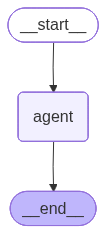

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))